In [29]:
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import SBM.utils.utils as ut

In [21]:
list_of_dicts = []

for f in glob.glob("../models/SectorSubaln0/*.npy"):
    n_chains = int(f.split("_")[3][6:])
    filename = f
    list_of_dicts.append({"n_chains": n_chains, "file": f})

df = pd.DataFrame(list_of_dicts)

In [22]:
nchain_values = []
stdnorms = []
for file in df.sort_values(by="n_chains")["file"]:
    n_chains = int(file.split("_")[3][6:])
    model = np.load(file, allow_pickle=True).item()
    Js = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        #J_norm = np.linalg.norm(J, 'fro', axis=(2,3))
        #print(J_norm.shape)
        Js.append(J)
    Js = np.array(Js)
    stdnorms.append(np.linalg.norm(np.std(Js, axis=0).flatten()))
    nchain_values.append(n_chains)

In [23]:
nchain_values = np.array(nchain_values)
stdnorms = np.array(stdnorms)

In [24]:
nchain_values, stdnorms

(array([   1,    5,   10,   25,   50,   75,  100,  200,  300,  400,  500,
        1000, 2000, 5000]),
 array([131.89427043,  21.40620363,   9.84208143,   7.62744518,
          7.47386101,   6.32595378,   7.38666448,   9.37347885,
         10.8897195 ,  13.19943863,  13.43287597,  17.78568158,
         18.95269499,  18.68717909]))

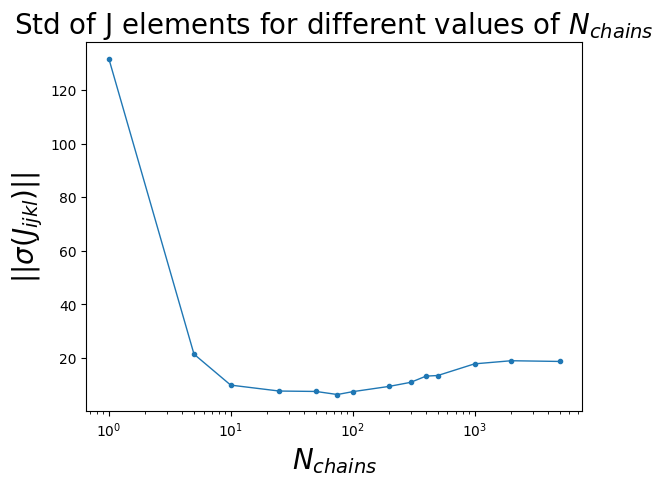

In [37]:
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['lines.linewidth'] = 1

plt.figure()
plt.plot(nchain_values, stdnorms, ".-")
plt.xscale("log")
plt.xlabel(r"$N_{chains}$")
plt.ylabel(r"$||\sigma(J_{ijkl})||$")
plt.title("Std of J elements for different values of $N_{chains}$")
plt.show()